# Version 2: a careful Random Forest experiment

In this section, we will test a Random Forest router on the same grouped nested-validation design used for logistic regression. A forest is a committee of decision trees: each tree makes a sequence of simple splits, and the committee combines the trees into a score for whether a query is relevant and should reach the nursing team.

The complete bounded search has 24 forest settings across embedding spaces A, B, and C, or 72 candidates per search. The result is the best configuration within that bounded search, not a global maximum. The blind test has no labels, so it can receive predictions but cannot produce test quality metrics.

In [2]:
from pathlib import Path
import sys

VERSION_DIR = Path(r"C:\Aditya\Prep\noora\version 2")
SRC_DIR = VERSION_DIR / "src"
OUTPUT_DIR = VERSION_DIR / "outputs"

print("VERSION_DIR:", VERSION_DIR)
print("Version dir exists:", VERSION_DIR.exists())
print("src exists:", SRC_DIR.exists())
print("reporting.py exists:", (SRC_DIR / "reporting.py").exists())
print("outputs exists:", OUTPUT_DIR.exists())

sys.path.insert(0, str(SRC_DIR))

import reporting

print("\nReporting module loaded from:")
print(reporting.__file__)

VERSION_DIR: C:\Aditya\Prep\noora\version 2
Version dir exists: True
src exists: True
reporting.py exists: True
outputs exists: True

Reporting module loaded from:
C:\Aditya\Prep\noora\version 2\src\reporting.py


In [4]:
from pathlib import Path

VERSION_DIR = Path(r"C:\Aditya\Prep\noora\version 2")

print("Files currently in outputs:\n")
for p in sorted((VERSION_DIR / "outputs").iterdir()):
    print(" -", p.name)

print("\nTrying load_artifacts...\n")

try:
    data = load_artifacts(VERSION_DIR)
    print("SUCCESS — all required artifacts found.")
except FileNotFoundError as e:
    print("MISSING:")
    print(e)

Files currently in outputs:

 - actual_grid.csv
 - artifact_schema.json
 - candidate_results.csv
 - comparative_metrics.csv
 - configuration.json
 - environment.json
 - final_model.joblib
 - fold_choices.csv
 - inner_search_records.csv
 - lr_validation.json
 - metrics.csv
 - outer_predictions.csv
 - protocol.json
 - requirements_versions.json
 - splits.csv
 - summary.json
 - test_predictions.csv
 - threshold_sweep.csv

Trying load_artifacts...

SUCCESS — all required artifacts found.


In [5]:
data = load_artifacts(VERSION_DIR)

metrics = data["metrics"]
outer_predictions = data["outer_predictions"]
candidate_results = data["candidate_results"]
threshold_sweep = data["threshold_sweep"]
test_predictions = data["test_predictions"]

print("Artifacts loaded successfully.\n")

print("metrics:", metrics.shape)
print("outer_predictions:", outer_predictions.shape)
print("candidate_results:", candidate_results.shape)
print("threshold_sweep:", threshold_sweep.shape)
print("test_predictions:", test_predictions.shape)

print("\nOuter folds:", outer_predictions["outer_fold"].nunique())

display(metrics.head())

Artifacts loaded successfully.

metrics: (26, 23)
outer_predictions: (903, 24)
candidate_results: (432, 16)
threshold_sweep: (905, 20)
test_predictions: (904, 17)

Outer folds: 5


,system,embedding,policy,evaluation,n,accuracy,macro_f1,precision,recall,specificity,...,fn,medical_fn,medical_n,medical_recall,referral_fraction,referrals,score_available,note,roc_auc,average_precision
0,tuned_rf,tuned,default_0_5,outer_oof_aggregate,903,0.870432,0.861105,0.879310,0.915619,0.797688,...,47,7,334,0.979042,0.642303,580,True,Nested selected RF; pooled OOF scores are desc...,0.945377,0.965407
1,tuned_rf,tuned,default_0_5,outer_fold_0,181,0.845304,0.835112,0.860870,0.891892,0.771429,...,12,2,72,0.972222,0.635359,115,True,Single outer-fold held-out result.,0.932175,0.957796
2,tuned_rf,tuned,default_0_5,outer_fold_1,181,0.889503,0.883526,0.918182,0.901786,0.869565,...,11,1,54,0.981481,0.607735,110,True,Single outer-fold held-out result.,0.944488,0.968074
3,tuned_rf,tuned,default_0_5,outer_fold_2,180,0.855556,0.842403,0.851240,0.927928,0.739130,...,8,1,71,0.985915,0.672222,121,True,Single outer-fold held-out result.,0.952996,0.966320
4,tuned_rf,tuned,default_0_5,outer_fold_3,180,0.905556,0.898645,0.905172,0.945946,0.840580,...,6,1,71,0.985915,0.644444,116,True,Single outer-fold held-out result.,0.957958,0.972051


In [6]:
print("Testing reporting tables...\n")

try:
    comp = comparison_table(data)
    print("comparison_table: OK", comp.shape)
    display(comp.head())
except Exception as e:
    print("comparison_table FAILED:", type(e).__name__, e)

print()

try:
    folds = fold_variation_table(data)
    print("fold_variation_table: OK", folds.shape)
    display(folds.head())
except Exception as e:
    print("fold_variation_table FAILED:", type(e).__name__, e)

print()

try:
    agg = rf_aggregate_metrics(data)
    print("rf_aggregate_metrics: OK")
    display(agg)
except Exception as e:
    print("rf_aggregate_metrics FAILED:", type(e).__name__, e)

Testing reporting tables...

comparison_table: OK (3, 24)


,display_label,system,embedding,policy,evaluation,n,accuracy,macro_f1,precision,recall,...,fn,medical_fn,medical_n,medical_recall,referral_fraction,referrals,score_available,note,roc_auc,average_precision
0,RF,tuned_rf,tuned,default_0_5,outer_oof_aggregate,903,0.870432,0.861105,0.879310,0.915619,...,47,7,334,0.979042,0.642303,580,True,Nested selected RF; pooled OOF scores are desc...,0.945377,0.965407
1,LR,tuned_lr,tuned,default_0_5,outer_oof_aggregate,903,0.872647,0.863479,0.881034,0.917415,...,46,14,334,0.958084,0.642303,580,True,Recomputed from saved Version 1 outer predicti...,0.936629,0.958379
2,LLM,llm_train,NaN,frozen_label,outer_oof_aggregate,903,0.978959,0.977682,0.978648,0.987433,...,7,0,334,1.000000,0.622370,562,False,Recomputed from saved Version 1 outer predicti...,NaN,NaN



fold_variation_table: OK (3, 9)


,policy,recall_min,recall_max,macro_f1_min,macro_f1_max,fn_min,fn_max,medical_fn_min,medical_fn_max
0,balanced_macro_f1,0.866071,0.936937,0.829716,0.899259,7,15,1,3
1,default_0_5,0.891892,0.945946,0.835112,0.898645,6,12,1,2
2,recall_first,0.946429,0.991071,0.809714,0.847257,1,6,0,0



rf_aggregate_metrics: OK


,policy,system,embedding,evaluation,n,accuracy,macro_f1,precision,recall,specificity,...,medical_n,medical_recall,referral_fraction,referrals,score_available,note,roc_auc,average_precision,policy_label,total_workload
0,default_0_5,tuned_rf,tuned,outer_oof_aggregate,903,0.870432,0.861105,0.879310,0.915619,0.797688,...,334,0.979042,0.642303,580,True,Nested selected RF; pooled OOF scores are desc...,0.945377,0.965407,Default 0.50,580
1,balanced_macro_f1,tuned_rf,tuned,outer_oof_aggregate,903,0.868217,0.860061,0.888298,0.899461,0.817919,...,334,0.970060,0.624585,564,True,Nested selected RF; pooled OOF scores are desc...,0.945377,0.965407,Balanced macro-F1,564
2,recall_first,tuned_rf,tuned,outer_oof_aggregate,903,0.848283,0.826494,0.815315,0.974865,0.644509,...,334,1.000000,0.737542,666,True,Nested selected RF; pooled OOF scores are desc...,0.945377,0.965407,Recall-first,666


In [7]:
try:
    folds = fold_variation_table(data)
    print("fold_variation_table: OK", folds.shape)
    display(folds)
except Exception as e:
    print("fold_variation_table FAILED:", type(e).__name__, e)

fold_variation_table: OK (3, 9)


,policy,recall_min,recall_max,macro_f1_min,macro_f1_max,fn_min,fn_max,medical_fn_min,medical_fn_max
0,balanced_macro_f1,0.866071,0.936937,0.829716,0.899259,7,15,1,3
1,default_0_5,0.891892,0.945946,0.835112,0.898645,6,12,1,2
2,recall_first,0.946429,0.991071,0.809714,0.847257,1,6,0,0


In [8]:
rf_html = build_executive_summary_html(data)

print("Generated HTML characters:", len(rf_html))
print("\nFirst 300 characters:\n")
print(rf_html[:300])

display(HTML(rf_html))

Generated HTML characters: 5151

First 300 characters:


<article class="exec-paper">
<div class="top-rule"></div>
<div class="document-kicker">Random Forest experiment note</div>
<h1>Intent classification router</h1>
<div class="author">Version 2 · measured development evidence</div>
<div class="abstract"><div class="abstract-label">Executive summary</d


Policy,Relevant missed,Unnecessary referrals,Total referrals,Precision,Relevant recall,Medical missed,Medical recall,Macro-F1
Default 0.50,47,70,580,87.9%,91.6%,7/334,97.9%,86.1%
Balanced macro-F1,56,63,564,88.8%,89.9%,10/334,97.0%,86.0%
Recall-first,14,123,666,81.5%,97.5%,0/334,100.0%,82.6%
System,Accuracy,Macro-F1,Precision,Relevant recall,Medical recall,AP,FN,FP
RF,87.0%,86.1%,87.9%,91.6%,97.9%,0.965,47,70
LR,87.3%,86.3%,88.1%,91.7%,95.8%,0.958,46,69
LLM,97.9%,97.8%,97.9%,98.7%,100.0%,—,7,12


In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import Image, display, HTML

ROOT = Path.cwd()
VERSION_DIR = ROOT / "version 2"
sys.path.insert(0, str(VERSION_DIR / "src"))

from reporting import (
    load_artifacts, final_recipe, plot_tuning_rank, plot_roc_pr,
    plot_threshold_development, plot_confusion_matrices, plot_calibration,
    comparison_table, fold_variation_table, build_executive_summary_html,
    rf_aggregate_metrics, calibration_bin_table,
)
import json

data = load_artifacts(VERSION_DIR)
metrics = data["metrics"]
outer_predictions = data["outer_predictions"]
candidate_results = data["candidate_results"]
threshold_sweep = data["threshold_sweep"]
print("Validated Version 2 RF artifacts.")
print(f"Development rows: {len(outer_predictions):,}; outer folds: {outer_predictions['outer_fold'].nunique()}; test rows: {len(data['test_predictions']):,}.")

FileNotFoundError: Required RF artifact is missing: C:\Aditya\Prep\noora\version 2\version 2\outputs\metrics.csv

## 1. Read the saved evidence

Here, we will load the core tables and check the scope before interpreting anything. The core owns model fitting, split construction, calibration, threshold selection, and the final refit. This notebook reads its saved evidence and makes the results understandable.

In [9]:
label_counts = outer_predictions["true_label"].value_counts().rename_axis("label").reset_index(name="rows")
fold_counts = outer_predictions.groupby("outer_fold", as_index=False).size().rename(columns={"size": "held-out rows"})
print("Label counts:")
display(label_counts)
print("Outer-fold sizes:")
display(fold_counts)
outer_candidates = candidate_results[candidate_results["selection_scope"].eq("outer_fold")]
print("Candidate rows in saved outer searches:", len(outer_candidates))
print("Required count: 5 outer folds x 72 candidates = 360 rows, before final all-training rows.")

Label counts:


,label,rows
0,relevant,557
1,irrelevant,346


Outer-fold sizes:


,outer_fold,held-out rows
0,0,181
1,1,181
2,2,180
3,3,180
4,4,181


Candidate rows in saved outer searches: 360
Required count: 5 outer folds x 72 candidates = 360 rows, before final all-training rows.


The labeled development set contains the examples used for grouped model selection and held-out evaluation. The outer fold is kept out while its model, probability method, and thresholds are chosen. Exact duplicate groups stay together. The blind test is structurally checked but has no labels.

In [10]:
recipe = final_recipe(data)
print("Final all-training recipe from summary.json:")
for key in ["final_embedding", "final_config_id", "final_forest_params", "final_probability_method", "final_mean_inner_average_precision"]:
    if key in recipe:
        print(f"  {key}: {recipe[key]}")
print("This recipe is read from the core final selection; it is not reconstructed from pooled outer candidate scores.")

Final all-training recipe from summary.json:
  final_embedding: b
  final_config_id: rf_09
  final_forest_params: {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': 2}
  final_probability_method: sigmoid
  final_mean_inner_average_precision: 0.9683246359604017
This recipe is read from the core final selection; it is not reconstructed from pooled outer candidate scores.


## 2. Understand the forest controls

In this section, we will see the complete tuning grid and why each control matters. A tree asks questions about the embedding coordinates one at a time. `max_depth` is the maximum number of questions along one path: deeper paths can describe more detailed patterns. `min_samples_leaf` is the smallest group allowed at the end of a path: a smaller leaf can fit finer detail, while a larger leaf forces more smoothing. `max_features` is the fraction or rule for how many coordinates the tree may consider at each question; changing it makes the committee's trees less alike. `class_weight=balanced` gives more influence to the smaller routing class. The number of trees is fixed at 200. These settings control the kind of evidence the forest can fit; they do not make a clinical guarantee.

In [11]:
ranked = candidate_results[candidate_results["selection_scope"].eq("final_all_training")].copy()
if ranked.empty:
    ranked = candidate_results[candidate_results["selection_scope"].eq("outer_fold")].copy()
params = ranked["forest_params"].map(json.loads)
ranked["n_estimators"] = params.map(lambda value: value["n_estimators"])
ranked["max_depth"] = ranked["max_depth"].where(ranked["max_depth"].notna(), params.map(lambda value: value["max_depth"]))
ranked["min_samples_leaf"] = ranked["min_samples_leaf"].where(ranked["min_samples_leaf"].notna(), params.map(lambda value: value["min_samples_leaf"]))
ranked["max_features"] = ranked["max_features"].where(ranked["max_features"].notna(), params.map(lambda value: value["max_features"]))
ranked["class_weight"] = ranked["class_weight"].where(ranked["class_weight"].notna(), params.map(lambda value: value["class_weight"]))
ranked["mean_inner_average_precision"] = pd.to_numeric(ranked["mean_inner_average_precision"], errors="raise")
ranked_view = ranked.sort_values("mean_inner_average_precision", ascending=False).head(10).copy()
display(ranked_view[["embedding", "n_estimators", "max_depth", "min_samples_leaf", "max_features", "class_weight", "mean_inner_average_precision"]])
print("The ranking is an inner-development tuning view. The final recipe above remains the authority for the final all-training fit.")

,embedding,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,mean_inner_average_precision
393,b,200,8.0,1,sqrt,balanced,0.968325
405,b,200,NaN,1,sqrt,balanced,0.967155
401,b,200,NaN,4,sqrt,balanced,0.966678
389,b,200,8.0,4,sqrt,balanced,0.966654
395,b,200,8.0,1,0.1,balanced,0.965099
402,b,200,NaN,4,0.1,NaN,0.964773
392,b,200,8.0,1,sqrt,NaN,0.964671
390,b,200,8.0,4,0.1,NaN,0.964660
394,b,200,8.0,1,0.1,NaN,0.964446
406,b,200,NaN,1,0.1,NaN,0.964318


The ranking is an inner-development tuning view. The final recipe above remains the authority for the final all-training fit.


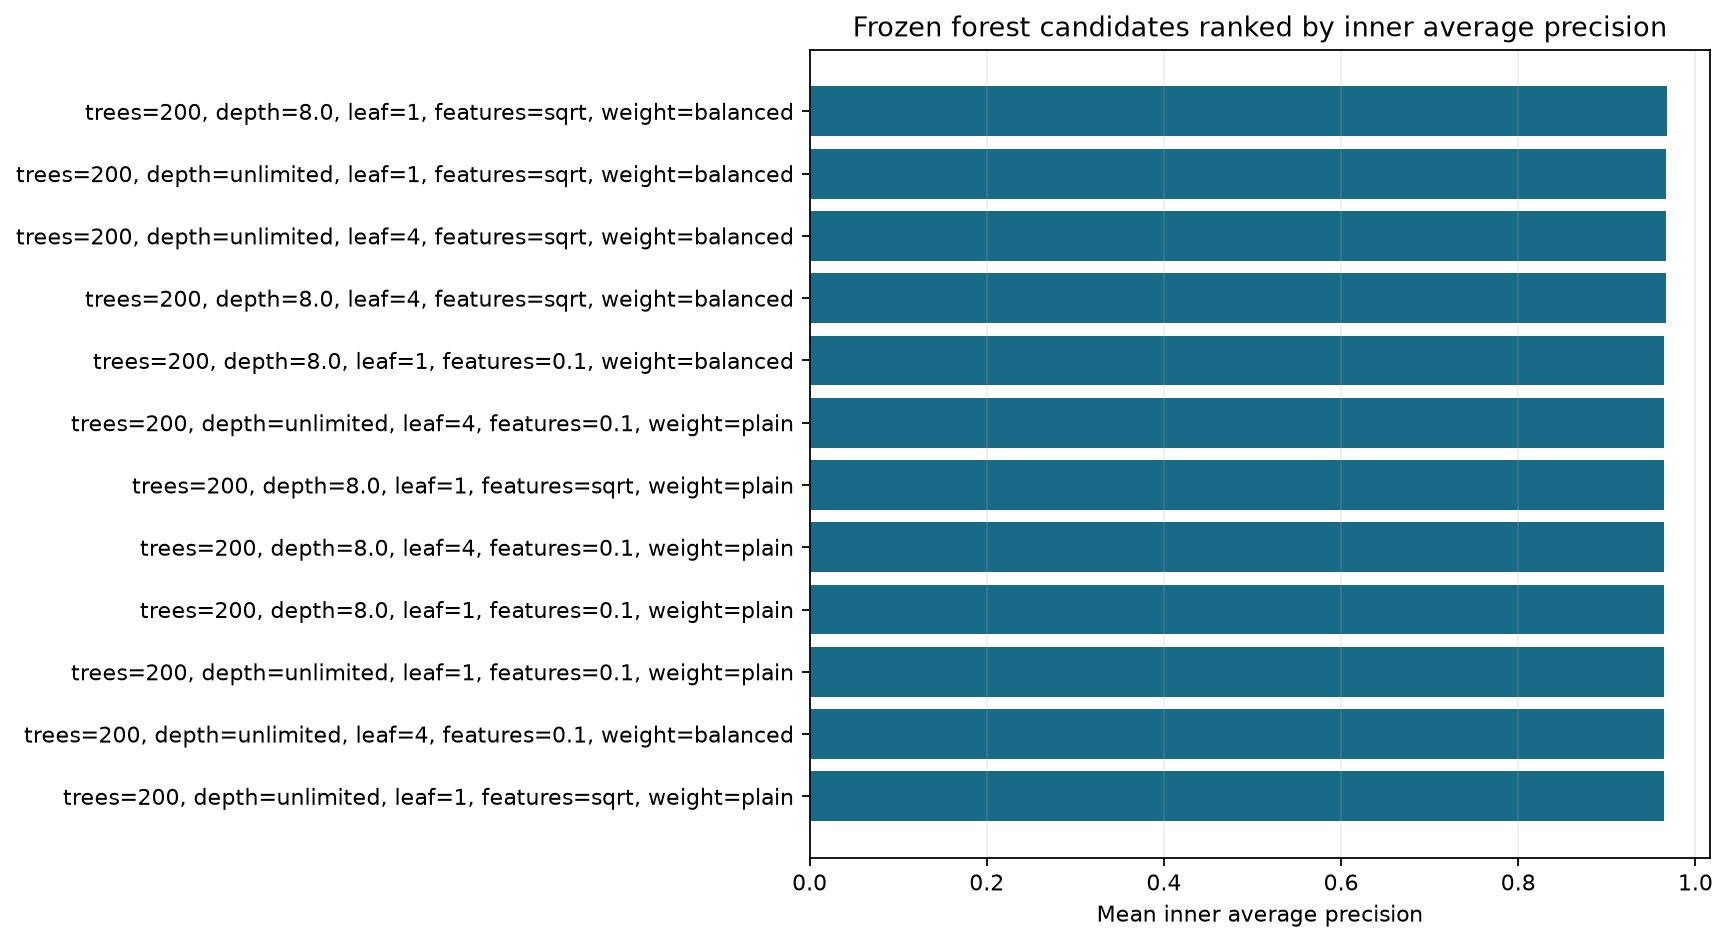

The plot shows the top 12 rows from the complete 24-setting forest grid across A, B, and C; the saved table still contains the full candidate evidence.


In [12]:
tuning_path = plot_tuning_rank(data)
display(Image(filename=str(tuning_path)))
print("The plot shows the top 12 rows from the complete 24-setting forest grid across A, B, and C; the saved table still contains the full candidate evidence.")

## 3. Measure ranking quality before choosing a threshold

Precision asks: of the rows we refer, how many are truly relevant? Recall asks: of all truly relevant rows, how many do we catch? A false positive is an unnecessary referral; a false negative is a missed relevant row. ROC plots false-alarm rate on the horizontal axis against catch rate, or relevant recall, on the vertical axis. Its AUC is 0.5 for random ranking and 1.0 for perfect ranking. Average precision summarizes the precision-recall curve as the cutoff moves; it is a ranking summary, not an accuracy score. These curves use saved selected probabilities from outer-held-out rows, and the supplied LLM has no probability curve.

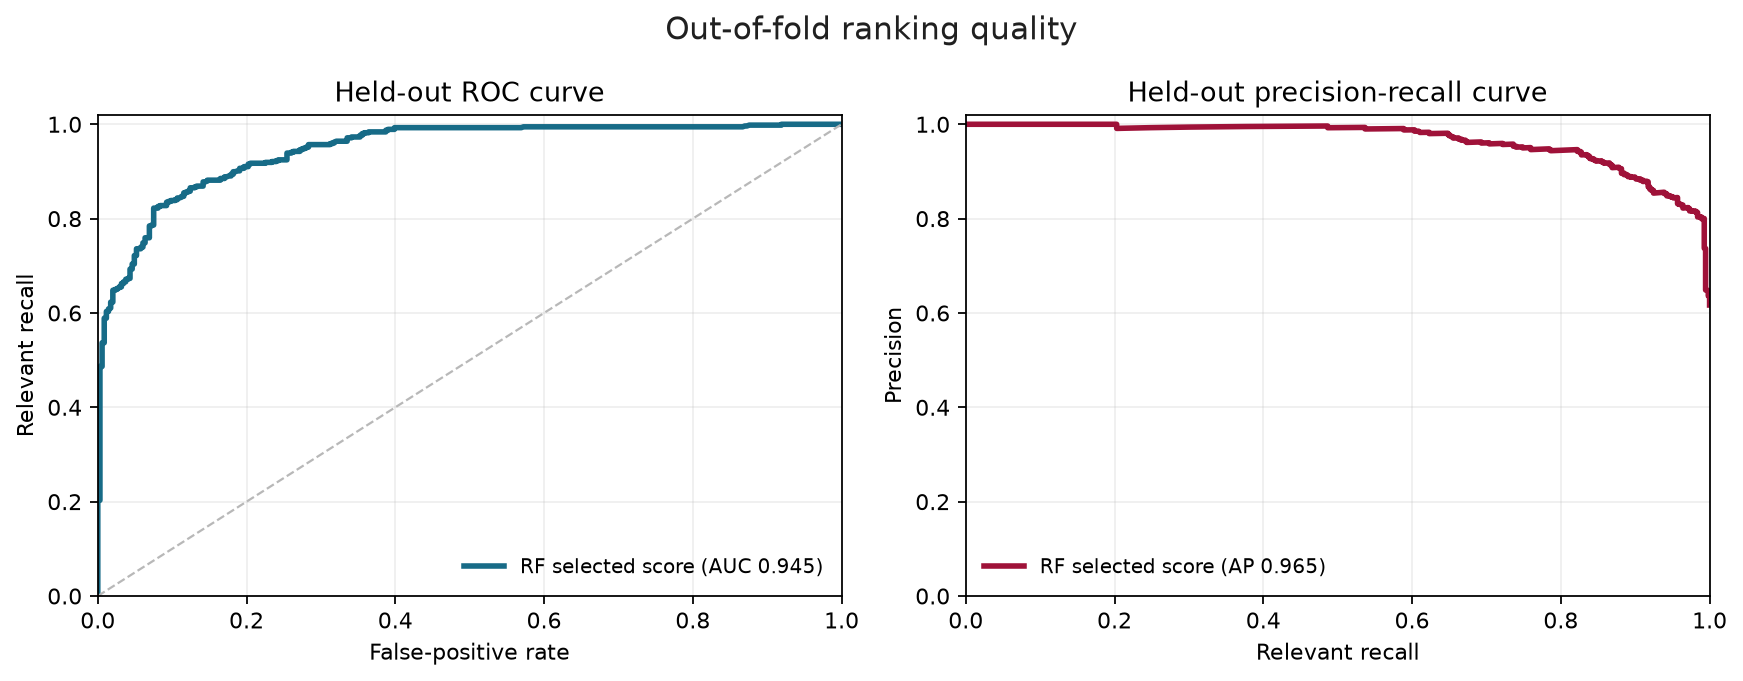

Held-out RF ROC AUC: 0.945; average precision: 0.965.


In [13]:
roc_pr_path = plot_roc_pr(data)
display(Image(filename=str(roc_pr_path)))
from sklearn.metrics import roc_auc_score, average_precision_score
y_outer = pd.to_numeric(outer_predictions["truth"], errors="raise")
p_outer = pd.to_numeric(outer_predictions["p_chosen"], errors="raise")
print(f"Held-out RF ROC AUC: {roc_auc_score(y_outer, p_outer):.3f}; average precision: {average_precision_score(y_outer, p_outer):.3f}.")

## 4. Make the threshold trade-off visible

Here, we will inspect the inner-development sweep used to choose the three operating policies. Lowering the threshold usually sends more queries onward and can reduce misses; the observed direction and size must be read from the saved counts. The vertical markers belong to the development sweep only.

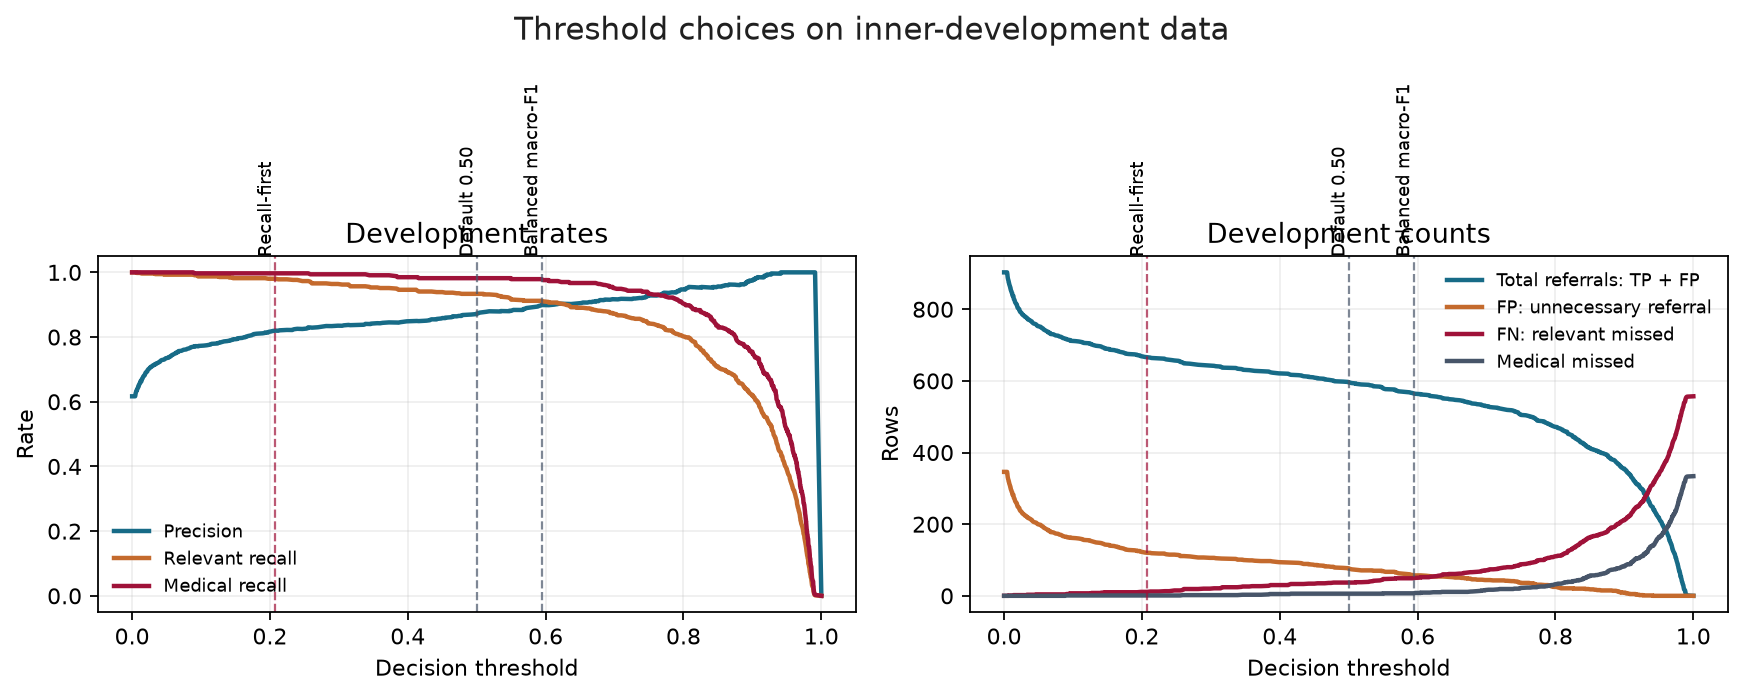

Default is 0.50. Balanced macro-F1 and recall-first use thresholds selected on inner-development data under the documented tie rules.


In [14]:
threshold_path = plot_threshold_development(data)
display(Image(filename=str(threshold_path)))
print("Default is 0.50. Balanced macro-F1 and recall-first use thresholds selected on inner-development data under the documented tie rules.")

## 5. Compare the three operating policies

The table below keeps rates and counts together because a threshold is an operating decision. Total referrals are TP + FP; unnecessary referrals are false positives. Recall-first is selected under assumed 98% relevant-recall and 99% Medical-recall targets when feasible. Those targets are development assumptions, not guarantees.

In [15]:
rf_rows = rf_aggregate_metrics(data)
policy_view = rf_rows[["policy_label", "precision", "recall", "fn", "fp", "total_workload", "medical_fn", "medical_n", "medical_recall", "macro_f1"]].copy()
policy_view.columns = ["Policy", "Precision", "Relevant recall", "Relevant missed", "Unnecessary referrals", "Total referrals", "Medical missed", "Medical total", "Medical recall", "Macro-F1"]
policy_view["Medical missed"] = policy_view["Medical missed"].astype(str) + "/" + policy_view["Medical total"].astype(str)
for column in ["Precision", "Relevant recall", "Medical recall", "Macro-F1"]:
    policy_view[column] = policy_view[column].map(lambda value: f"{value:.1%}")
display(policy_view[["Policy", "Precision", "Relevant recall", "Relevant missed", "Unnecessary referrals", "Total referrals", "Medical missed", "Medical recall", "Macro-F1"]])
default = rf_rows.set_index("policy").loc["default_0_5"]
recall_first = rf_rows.set_index("policy").loc["recall_first"]
print(f"Default -> recall-first: relevant misses {int(default['fn'])} -> {int(recall_first['fn'])}; Medical misses {int(default['medical_fn'])}/{int(default['medical_n'])} -> {int(recall_first['medical_fn'])}/{int(recall_first['medical_n'])}; total referrals {int(default['total_workload'])} -> {int(recall_first['total_workload'])}.")

,Policy,Precision,Relevant recall,Relevant missed,Unnecessary referrals,Total referrals,Medical missed,Medical recall,Macro-F1
0,Default 0.50,87.9%,91.6%,47,70,580,7/334,97.9%,86.1%
1,Balanced macro-F1,88.8%,89.9%,56,63,564,10/334,97.0%,86.0%
2,Recall-first,81.5%,97.5%,14,123,666,0/334,100.0%,82.6%


Default -> recall-first: relevant misses 47 -> 14; Medical misses 7/334 -> 0/334; total referrals 580 -> 666.


The saved outer-fold decisions are used for this comparison. The change from default to recall-first can improve recall while worsening precision or workload; the actual sign is shown by the counts above. No policy is called a winner without considering the local cost of misses and review capacity.

## 6. Inspect held-out confusion matrices

Each matrix below aggregates all 903 outer-held-out rows for one policy. Every label came from the saved fold-specific decision made without that row. Fold-to-fold variation appears in a separate table, so the matrices show the requested policy comparison without pretending that one pooled row is a single fitted model.

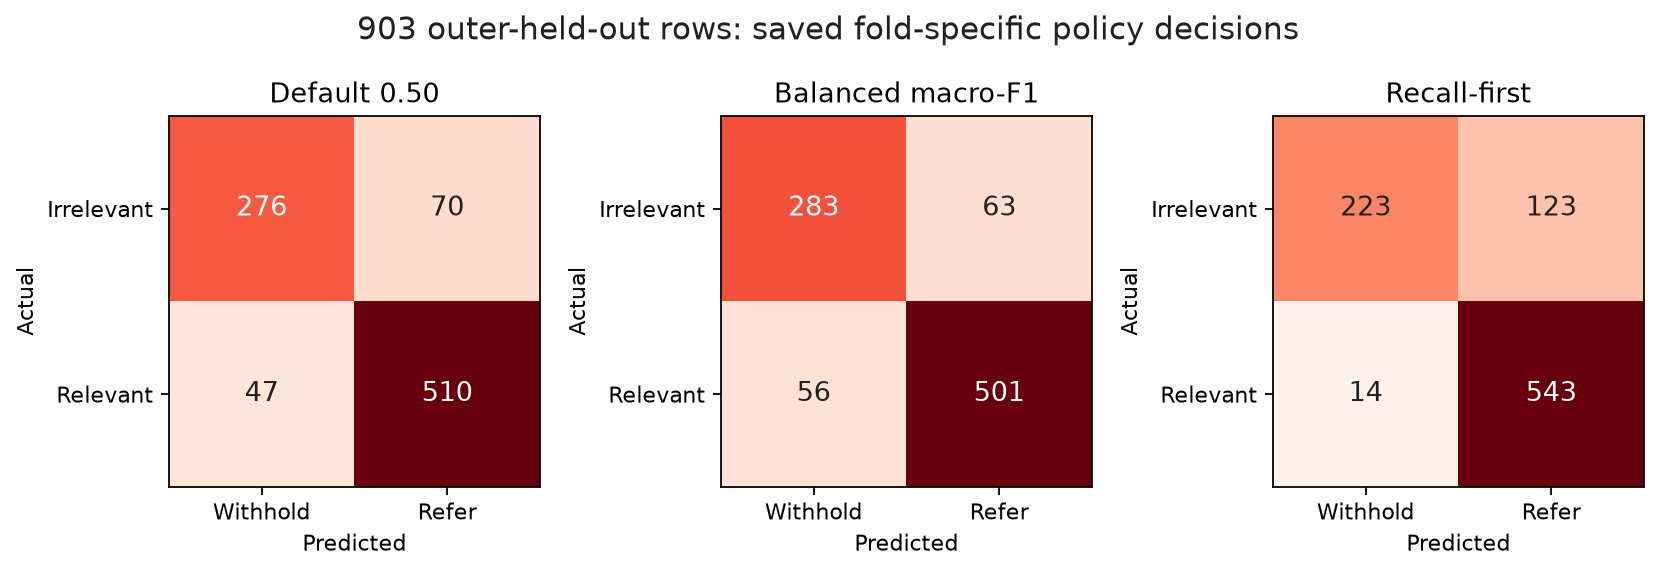

These three matrices aggregate 903 saved outer-held-out decisions: default, balanced macro-F1, and recall-first.


In [16]:
confusion_path = plot_confusion_matrices(data)
display(Image(filename=str(confusion_path)))
print("These three matrices aggregate 903 saved outer-held-out decisions: default, balanced macro-F1, and recall-first.")

## 7. Check probability behavior

A predicted probability of 0.80 means that roughly eight of ten similar rows would be relevant if the probabilities were well calibrated. We compare raw and selected scores with a reliability plot, Brier scores, and counts in each selected-probability bin. Calibration is a diagnostic, not a safety certificate.

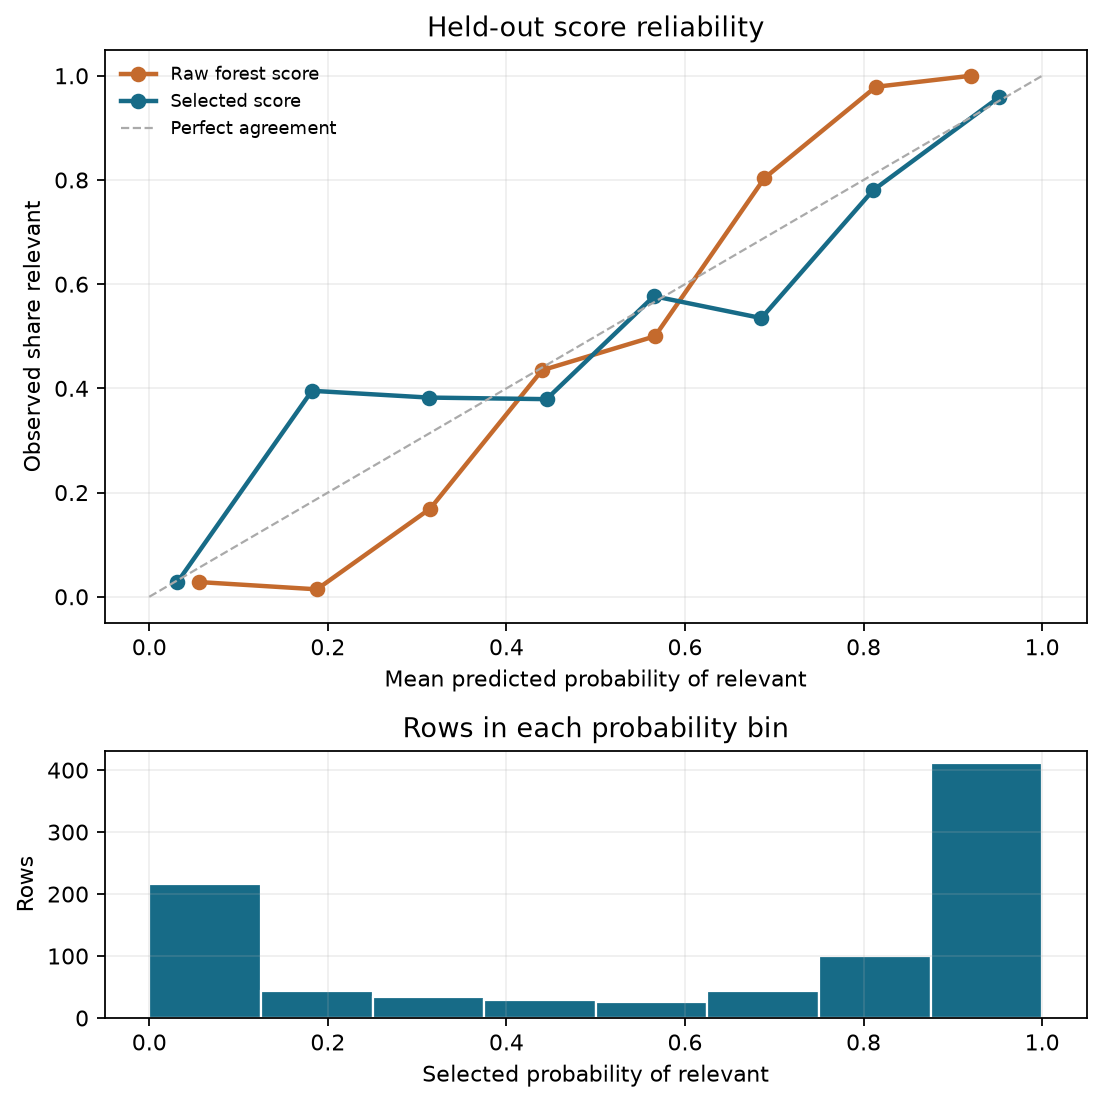

Outer Brier score, raw: 0.105; selected: 0.092.
Calibration bins (interval, count, predicted rate, observed relevant rate):


,probability_bin,rows,mean_predicted_probability,observed_relevant_rate
0,"(-0.001, 0.125]",217,0.031317,0.027650
1,"(0.125, 0.25]",43,0.182159,0.395349
2,"(0.25, 0.375]",34,0.312875,0.382353
3,"(0.375, 0.5]",29,0.444899,0.379310
4,"(0.5, 0.625]",26,0.565233,0.576923
5,"(0.625, 0.75]",43,0.685534,0.534884
6,"(0.75, 0.875]",100,0.810488,0.780000
7,"(0.875, 1.0]",411,0.951590,0.958637


The selected score is the probability method frozen by inner Brier selection.


In [17]:
calibration_path = plot_calibration(data)
display(Image(filename=str(calibration_path)))
from sklearn.metrics import brier_score_loss
raw = pd.to_numeric(outer_predictions["p_raw"], errors="raise")
chosen = pd.to_numeric(outer_predictions["p_chosen"], errors="raise")
print(f"Outer Brier score, raw: {brier_score_loss(y_outer, raw):.3f}; selected: {brier_score_loss(y_outer, chosen):.3f}.")
print("Calibration bins (interval, count, predicted rate, observed relevant rate):")
display(calibration_bin_table(data))
print("The selected score is the probability method frozen by inner Brier selection.")

## 8. Compare RF, LR, and the supplied LLM

This is an aggregate comparison table only. RF and LR use the same outer development scope. The LLM has labels only, so its ROC AUC and average precision are undefined. Fold variation is shown separately so a single pooled row is not mistaken for stability.

In [18]:
comparison = comparison_table(data)
comparison_view = comparison[["display_label", "accuracy", "macro_f1", "precision", "recall", "medical_recall", "average_precision", "fn", "fp"]].copy()
comparison_view.columns = ["System", "Accuracy", "Macro-F1", "Precision", "Relevant recall", "Medical recall", "Average precision", "FN", "FP"]
for column in ["Accuracy", "Macro-F1", "Precision", "Relevant recall", "Medical recall"]:
    comparison_view[column] = comparison_view[column].map(lambda value: "—" if pd.isna(value) else f"{value:.1%}")
comparison_view["Average precision"] = comparison_view["Average precision"].map(lambda value: "—" if pd.isna(value) else f"{value:.3f}")
display(comparison_view)
print("RF outer-fold variation:")
display(fold_variation_table(data))

,System,Accuracy,Macro-F1,Precision,Relevant recall,Medical recall,Average precision,FN,FP
0,RF,87.0%,86.1%,87.9%,91.6%,97.9%,0.965,47,70
1,LR,87.3%,86.3%,88.1%,91.7%,95.8%,0.958,46,69
2,LLM,97.9%,97.8%,97.9%,98.7%,100.0%,—,7,12


RF outer-fold variation:


,policy,recall_min,recall_max,macro_f1_min,macro_f1_max,fn_min,fn_max,medical_fn_min,medical_fn_max
0,balanced_macro_f1,0.866071,0.936937,0.829716,0.899259,7,15,1,3
1,default_0_5,0.891892,0.945946,0.835112,0.898645,6,12,1,2
2,recall_first,0.946429,0.991071,0.809714,0.847257,1,6,0,0


The comparison describes measured development behavior. It does not establish that RF improves LR, and it does not turn the LLM label-only baseline into a score model. The next cell assembles the final white-paper-style summary from the same validated artifacts.

In [19]:
summary_html = build_executive_summary_html(data)
display(HTML(summary_html))

Policy,Relevant missed,Unnecessary referrals,Total referrals,Precision,Relevant recall,Medical missed,Medical recall,Macro-F1
Default 0.50,47,70,580,87.9%,91.6%,7/334,97.9%,86.1%
Balanced macro-F1,56,63,564,88.8%,89.9%,10/334,97.0%,86.0%
Recall-first,14,123,666,81.5%,97.5%,0/334,100.0%,82.6%
System,Accuracy,Macro-F1,Precision,Relevant recall,Medical recall,AP,FN,FP
RF,87.0%,86.1%,87.9%,91.6%,97.9%,0.965,47,70
LR,87.3%,86.3%,88.1%,91.7%,95.8%,0.958,46,69
LLM,97.9%,97.8%,97.9%,98.7%,100.0%,—,7,12


In [20]:
from pathlib import Path

output_path = Path(r"C:\Aditya\Prep\noora\version 2\RANDOM_FOREST_REPORT.html")

rf_html = build_executive_summary_html(data)

standalone_html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Random Forest Report</title>

<style>
body {{
    margin: 0;
    background: #ece8e4;
}}

.exec-paper {{
    max-width: 980px;
    margin: 28px auto;
    padding: 58px 72px 70px;
    background: white;
    color: #202020;
    font: 15px/1.68 Georgia, serif;
}}

.top-rule {{
    height: 5px;
    background: #9f1239;
    margin-bottom: 42px;
}}

.document-kicker,
.abstract-label {{
    font: 700 11px Arial, sans-serif;
    text-transform: uppercase;
    letter-spacing: 1.3px;
    color: #9f1239;
}}

.exec-paper h1 {{
    font: 400 36px Georgia, serif;
    color: #9f1239;
}}

.exec-paper h2 {{
    font: 700 19px Arial, sans-serif;
    border-bottom: 2px solid #ddd;
    padding-bottom: 7px;
    margin-top: 42px;
}}

.metric-strip {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    border-top: 1px solid #bbb;
    border-bottom: 1px solid #bbb;
    margin: 24px 0;
}}

.metric-strip div {{
    padding: 15px;
    border-right: 1px solid #ddd;
}}

.metric-strip strong {{
    display: block;
    font: 700 25px Arial, sans-serif;
    color: #176b87;
}}

.metric-strip span {{
    display: block;
    color: #64748b;
    font: 12px Arial, sans-serif;
}}

.abstract {{
    border-top: 1px solid #bbb;
    border-bottom: 1px solid #bbb;
    padding: 18px 0;
    margin-bottom: 28px;
}}

table {{
    width: 100%;
    border-collapse: collapse;
    font: 12px Arial, sans-serif;
    margin: 16px 0;
}}

th {{
    background: #123447;
    color: white;
    padding: 9px;
}}

td {{
    padding: 9px;
    border-bottom: 1px solid #e5e7eb;
    text-align: right;
}}

th:first-child,
td:first-child {{
    text-align: left;
}}

.recipe,
.finding,
.conditional {{
    padding: 16px 20px;
    margin: 20px 0;
    background: #f7f4f1;
    border-left: 5px solid #9f1239;
}}
</style>
</head>

<body>
{rf_html}
</body>
</html>
"""

output_path.write_text(standalone_html, encoding="utf-8")

print("Saved HTML to:")
print(output_path)

Saved HTML to:
C:\Aditya\Prep\noora\version 2\RANDOM_FOREST_REPORT.html
